# Smart MCQ Solver Challenge

Multiple-choice QA (5 options A–E). Task: predict top-3 ranked answers per question.  
Metric: **MAP@3**.

Pipeline:
1. Load & sanity-check the data
2. EDA — answer distribution, prompt/option lengths, longest-option heuristic
3. Prompt normalization (strip wrapper phrases → `stem`)
4. Pairwise ranking format (each Q → 5 rows, one per option)
5. TF-IDF (word on full text + char on differing tail) + numeric features
6. **Model 1** — Logistic Regression, 5-fold GroupKFold by `qid`
7. **Model 2** — TextCNN ranker (bert-base-uncased tokenizer, custom head)
8. **Model 3** — BERT ranker (`AutoModelForSequenceClassification`, num_labels=1)
9. Submission — BERT top-3 per question

## Importing Libraries

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

OPTIONS = ['A', 'B', 'C', 'D', 'E']

## Dataset Loading

In [2]:
COMP = '/kaggle/input/competitions/smart-mcq-solver-challenge'

train_df = pd.read_csv(f'{COMP}/train.csv')
test_df  = pd.read_csv(f'{COMP}/test.csv')
sample   = pd.read_csv(f'{COMP}/sample_submission.csv')

print('train:', train_df.shape, '| test:', test_df.shape)

train: (2000, 8) | test: (500, 7)


In [3]:
train_df.head(3)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [4]:
test_df.head(3)

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...


### Shape, dtypes, missing values, duplicate IDs

In [5]:
print(f'train shape: {train_df.shape}  | test shape: {test_df.shape}')
print(f'train cols : {train_df.columns.tolist()}')
print(f'test cols  : {test_df.columns.tolist()}')

train shape: (2000, 8)  | test shape: (500, 7)
train cols : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
test cols  : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


In [6]:
#Missing values testing
print('train NaNs:'); print(train_df.isna().sum())
print('\n')
print('test NaNs:');  print(test_df.isna().sum())

train NaNs:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


test NaNs:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [7]:
print('train duplicate ids:', train_df['id'].duplicated().sum())
print('test  duplicate ids:', test_df['id'].duplicated().sum())

train duplicate ids: 0
test  duplicate ids: 0


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


## Exploratory Data Analysis

### EDA 1 - Answer letter distribution

Distribution of the correct answer among options (A-E)

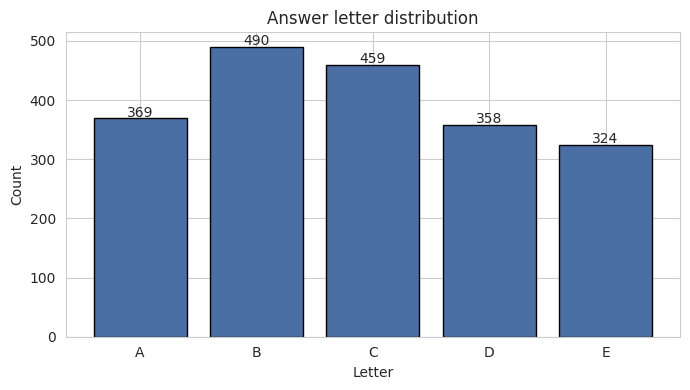

In [9]:
counts = train_df['answer'].value_counts().reindex(OPTIONS)

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color='#4A6FA5', edgecolor='black')
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha='center')
plt.title('Answer letter distribution')
plt.xlabel('Letter'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

### EDA 2 - Prompt length (characters)
How long are the question prompts?

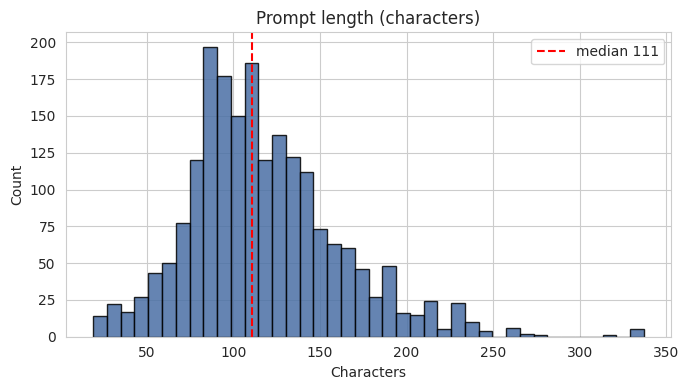

In [10]:
lengths = train_df['prompt'].str.len()

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=40, color='#4A6FA5', edgecolor='black', alpha=0.85)
plt.axvline(lengths.median(), color='red', linestyle='--', label=f'median {int(lengths.median())}')
plt.title('Prompt length (characters)')
plt.xlabel('Characters'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()

### EDA 3 - Option length by position
Average length of each of the options

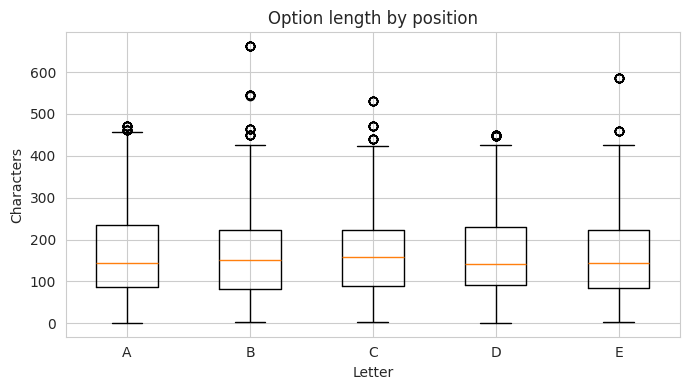

In [11]:
opt_lens = [train_df[L].astype(str).str.len().tolist() for L in OPTIONS]

plt.figure(figsize=(7, 4))
plt.boxplot(opt_lens, labels=OPTIONS)
plt.title('Option length by position')
plt.xlabel('Letter'); plt.ylabel('Characters')
plt.tight_layout(); plt.show()

### EDA 4 - Correct vs wrong option length

Correct answers tend to be longer than distractors.

In [12]:
correct_lens, wrong_lens = [], []
for _, row in train_df.iterrows():
    for L in OPTIONS:
        n = len(str(row[L]))
        if L == row['answer']:
            correct_lens.append(n)
        else:
            wrong_lens.append(n)

print(f'mean length — correct : {np.mean(correct_lens):.1f}')
print(f'mean length — wrong   : {np.mean(wrong_lens):.1f}')

mean length — correct : 181.9
mean length — wrong   : 160.7


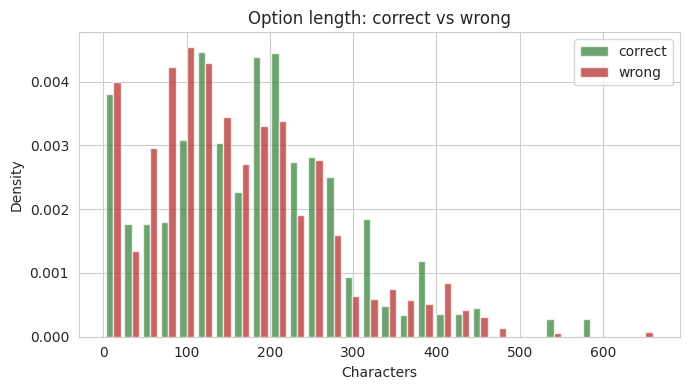

In [13]:
plt.figure(figsize=(7, 4))
plt.hist([correct_lens, wrong_lens], bins=30, label=['correct', 'wrong'],
         color=['#2E7D32', '#B22222'], alpha=0.7, density=True)
plt.title('Option length: correct vs wrong')
plt.xlabel('Characters'); plt.ylabel('Density'); plt.legend()
plt.tight_layout(); plt.show()

### EDA 5- Is the longest option the correct one?

In [14]:
hits = 0
for _, row in train_df.iterrows():
    lens = {L: len(str(row[L])) for L in OPTIONS}
    if max(lens, key=lens.get) == row['answer']:
        hits += 1

pct = 100 * hits / len(train_df)
print(f'longest option == correct: {pct:.1f}% of questions')

longest option == correct: 40.5% of questions


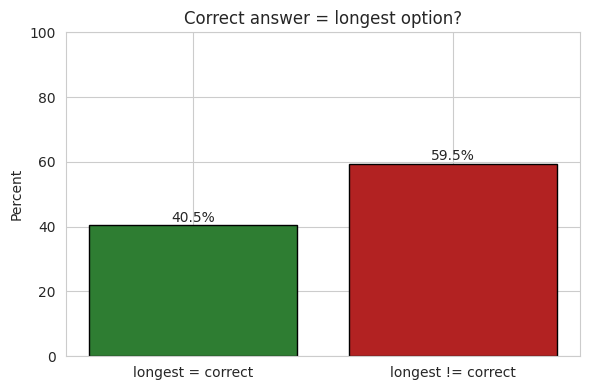

In [15]:
plt.figure(figsize=(6, 4))
plt.bar(['longest = correct', 'longest != correct'], [pct, 100 - pct],
        color=['#2E7D32', '#B22222'], edgecolor='black')
for i, v in enumerate([pct, 100 - pct]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.ylim(0, 100)
plt.title('Correct answer = longest option?')
plt.ylabel('Percent')
plt.tight_layout(); plt.show()

### EDA 6 — Train vs test prompt length and Correlation heatmap

Are train and test drawn from the same distribution?

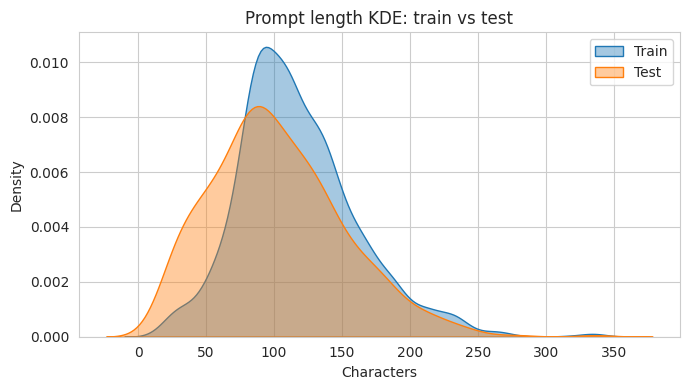

In [16]:
plt.figure(figsize=(7, 4))
sns.kdeplot(train_df['prompt'].str.len(), label='Train', fill=True, alpha=0.4)
sns.kdeplot(test_df['prompt'].str.len(),  label='Test',  fill=True, alpha=0.4)
plt.title('Prompt length KDE: train vs test')
plt.xlabel('Characters'); plt.legend()
plt.tight_layout(); plt.show()

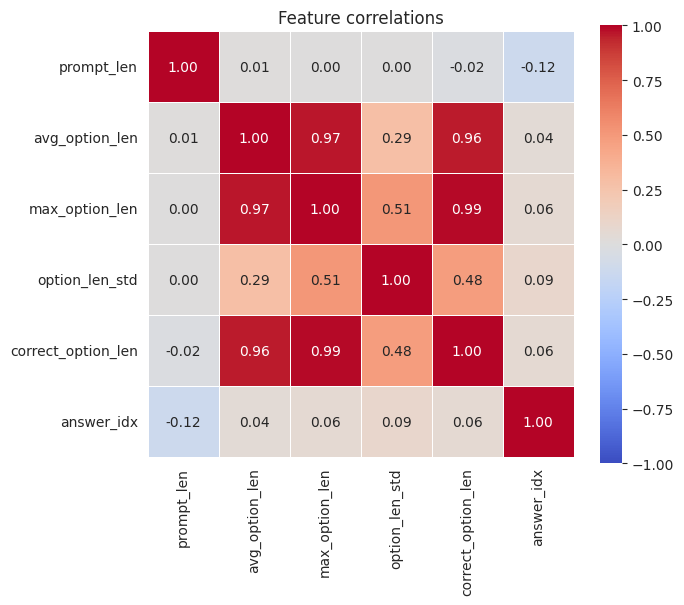

In [17]:
opt_lens = train_df[['A','B','C','D','E']].apply(lambda c: c.str.len())

feat = pd.DataFrame({
    'prompt_len':         train_df['prompt'].str.len(),
    'avg_option_len':     opt_lens.mean(axis=1),
    'max_option_len':     opt_lens.max(axis=1),
    'option_len_std':     opt_lens.std(axis=1),
    'correct_option_len': train_df.apply(lambda r: len(str(r[r['answer']])), axis=1),
    'answer_idx':         train_df['answer'].map({'A':0,'B':1,'C':2,'D':3,'E':4}),
})

plt.figure(figsize=(7, 6))
sns.heatmap(feat.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5) #cbar=False)
plt.title('Feature correlations')
plt.tight_layout()
plt.show()

## Prompt Normalization — strip wrapper phrases

Many prompts share reusable framing (e.g. `"Pick the best possible answer: ... among the listed options."`). Stripping them collapses paraphrased variants to a shared **stem** — useful both as an EDA observation and as a diagnostic feature.

In [18]:
PREFIXES = [
    r'^\s*pick the best possible answer\s*[:\-]?\s*',
    r'^\s*select the most accurate option\s*[:\-]?\s*',
    r'^\s*determine the correct option\s*[:\-]?\s*',
    r'^\s*identify the correct statement\s*[:\-]?\s*',
    r'^\s*choose the correct answer\s*[:\-]?\s*',
    r'^\s*which of the following is correct\??\s*',
]
SUFFIXES = [
    r'\s+based on the given context\.?\s*$',
    r'\s+based on the given information\.?\s*$',
    r'\s+from the following choices\.?\s*$',
    r'\s+among the listed options\.?\s*$',
    r'\s+carefully\.?\s*$',
    r'\s+above\.?\s*$',
]

def strip_framing(s):
    s = str(s)
    prev = None
    while prev != s:
        prev = s
        for p in PREFIXES:
            s = re.sub(p, '', s, flags=re.IGNORECASE)
        for p in SUFFIXES:
            s = re.sub(p, '', s, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', s).strip().lower()

train_df['stem'] = train_df['prompt'].apply(strip_framing)
test_df['stem']  = test_df['prompt'].apply(strip_framing)

print(f'unique prompts (train): {train_df["prompt"].nunique()}')
print(f'unique stems   (train): {train_df["stem"].nunique()}')

unique prompts (train): 1758
unique stems   (train): 252


## Modeling Data Preparation

`train_df` / `test_df` now carry EDA columns and `stem`. For modeling we copy only the original competition columns into `df_train` / `df_test`.

In [19]:
df_train = train_df[['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']].copy()
df_test  = test_df[['id', 'prompt', 'A', 'B', 'C', 'D', 'E']].copy()

print('df_train:', df_train.shape)
print('df_test :', df_test.shape)

df_train: (2000, 8)
df_test : (500, 7)


## Feature Engineering — Pairwise Ranking Format

Instead of 5-way classification we treat this as **ranking**:
- Each question with 5 options → **5 rows**, one per option
- Label = 1 if that option is the correct answer, else 0
- Model scores each row; top-3 scores per question become the prediction

Two text fields are built:
- `text_full` = `prompt + [ANS] + option` (used for word TF-IDF)
- `text_tail` = the **differing suffix** of the option after the common prefix shared with the other 4 options (used for char TF-IDF, so the model doesn't waste capacity on shared prefixes)

Plus six numeric features per row: `rel_len`, `overlap`, `tail_overlap`, `unique_ratio`, `div_point`, `tail_len_ratio`.

In [20]:
OPTION_COLS = ['A', 'B', 'C', 'D', 'E']

In [21]:
def split_option_suffix(row):
    """First index where the 5 options diverge, plus each option's suffix from there."""
    choices = [str(row[c]) for c in OPTION_COLS]
    shortest = min(len(o) for o in choices)
    split_idx = 0
    for pos in range(shortest):
        if len({o[pos] for o in choices}) > 1:
            split_idx = pos
            break
    suffix = {c: o[split_idx:] for c, o in zip(OPTION_COLS, choices)}
    return suffix, split_idx

# Sanity check on the first training row
demo_suffix, demo_idx = split_option_suffix(df_train.iloc[0])
print('divergence index:', demo_idx)
print({k: v[:40] for k, v in demo_suffix.items()})


divergence index: 17
{'A': 'believes that humans exist within a time', 'B': 'believes that humans do not exist inside', 'C': 'does not believe in the existence of tim', 'D': 'believes that the relationship between t', 'E': 'believes that time is an illusion, and t'}


In [22]:
def make_pairwise(df, is_train=True):
    """Expand each MCQ into 5 rows (one per option) with lexical + length features."""
    records = []
    for _, r in df.iterrows():
        suffix, split_idx = split_option_suffix(r)
        stem = str(r['prompt'])
        stem_toks = set(re.findall(r'\b\w{4,}\b', stem.lower()))
        lengths = [len(str(r[c])) for c in OPTION_COLS]
        mean_len = np.mean(lengths) + 1e-6
        pooled_toks = set()
        for c in OPTION_COLS:
            pooled_toks |= set(re.findall(r'\b\w{4,}\b', str(r[c]).lower()))
        for j, c in enumerate(OPTION_COLS):
            opt = str(r[c])
            opt_toks = set(re.findall(r'\b\w{4,}\b', opt.lower()))
            suf_toks = set(re.findall(r'\b\w{4,}\b', suffix[c].lower()))
            y = int(is_train and r['answer'] == c)
            records.append({
                'qid': r['id'],
                'option': c,
                'text_full': stem + ' [ANS] ' + opt,
                'text_tail': suffix[c],
                'rel_len': lengths[j] / mean_len,
                'overlap': len(stem_toks & opt_toks) / max(len(stem_toks), 1),
                'tail_overlap': len(stem_toks & suf_toks) / max(len(stem_toks), 1),
                'unique_ratio': len(opt_toks - (pooled_toks - opt_toks)) / max(len(opt_toks), 1),
                'div_point': split_idx,
                'tail_len_ratio': len(suffix[c]) / max(len(opt), 1),
                'label': y,
            })
    return pd.DataFrame(records)

In [23]:
pw_train = make_pairwise(df_train, is_train=True)
print('pw_train:', pw_train.shape)


pw_train: (10000, 11)


In [24]:
pw_test = make_pairwise(df_test, is_train=False)
print('pw_test:', pw_test.shape)


pw_test: (2500, 11)


In [25]:
pw_train.head(6)

,qid,option,text_full,text_tail,rel_len,overlap,tail_overlap,unique_ratio,div_point,tail_len_ratio,label
0,1,A,Pick the best possible answer: What is Martin ...,believes that humans exist within a time conti...,1.300847,0.2500,0.1250,1.0,17,0.944625,0
1,1,B,Pick the best possible answer: What is Martin ...,"believes that humans do not exist inside time,...",1.093220,0.2500,0.1250,1.0,17,0.934109,1
2,1,C,Pick the best possible answer: What is Martin ...,does not believe in the existence of time or t...,0.940678,0.3750,0.2500,1.0,17,0.923423,0
3,1,D,Pick the best possible answer: What is Martin ...,believes that the relationship between time an...,0.855932,0.4375,0.3125,1.0,17,0.915842,0
4,1,E,Pick the best possible answer: What is Martin ...,"believes that time is an illusion, and the pas...",0.809322,0.1875,0.0625,1.0,17,0.910995,0
5,2,A,What is accelerator-based light-ion fusion? [A...,light-ion fusion reactions. This method is rel...,1.041026,0.8000,0.4000,1.0,140,0.655172,1


## TF-IDF Vectorization

Two vectorizers stacked with the numeric features:
1. **Word TF-IDF** (1–2 grams) on `text_full` — captures prompt–option interaction
2. **Char TF-IDF** (2–5 grams, `char_wb`) on `text_tail` — captures fine-grained lexical signal in the *differing* part of each option

In [26]:
# Word Tf-idf
tfidf_word = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    analyzer='word',
)

# Char Tf-idf
tfidf_char = TfidfVectorizer(
    max_features=40000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    min_df=1,
    analyzer='char_wb',
)


In [27]:
Xw_tr  = tfidf_word.fit_transform(pw_train['text_full'])
Xw_tst = tfidf_word.transform(pw_test['text_full'])

Xc_tr  = tfidf_char.fit_transform(pw_train['text_tail'])
Xc_tst = tfidf_char.transform(pw_test['text_tail'])

#Grid Shape
print('Word TF-IDF:', Xw_tr.shape)
print('Char TF-IDF:', Xc_tr.shape)


Word TF-IDF: (10000, 13091)
Char TF-IDF: (10000, 22082)


In [28]:
num_feats = [
    'rel_len',
    'overlap',
    'tail_overlap',
    'unique_ratio',
    'div_point',
    'tail_len_ratio',
]

X_num_tr  = csr_matrix(pw_train[num_feats].values.astype(float))
X_num_tst = csr_matrix(pw_test[num_feats].values.astype(float))

#Horizontal stacking

X_tr  = hstack([Xw_tr, Xc_tr, X_num_tr])
X_tst = hstack([Xw_tst, Xc_tst, X_num_tst])
y_tr  = pw_train['label'].values

print('Full train matrix:', X_tr.shape)
print('Positive labels  :', int(y_tr.sum()), '/', len(y_tr))

Full train matrix: (10000, 35179)
Positive labels  : 2000 / 10000


## Evaluation Metric — MAP@3

Per question, submit 3 ranked letters. Reward = 1 if correct is at rank-1, 1/2 if at rank-2, 1/3 if at rank-3, else 0. Mean over all questions.

In [29]:
#Generic MAP Calculation
def apk(actual, predicted, k=3):
    score = 0.0
    hits = 0
    for i, p in enumerate(predicted[:k]):
        if p == actual:
            hits += 1
            score += hits / (i + 1.0)
    return score



def mapk(actuals, preds, k=3):
    return float(np.mean([apk(a, p, k) for a, p in zip(actuals, preds)]))


def rank_preds(pw, scores, orig_df):
    """Convert option-level scores into top-3 option lists per question."""
    pw = pw.copy()
    pw['score'] = scores
    preds = []
    for qid in orig_df['id']:
        q = pw[pw['qid'] == qid].sort_values('score', ascending=False)
        preds.append(q['option'].tolist()[:3])
    return preds


print('MAP@3 check:', apk('A', ['A', 'B', 'C']))


MAP@3 check: 1.0


## Model 1 — Logistic Regression

5-fold `GroupKFold` grouped by `qid`. This is required because the 5 pairwise rows of one question must not straddle the train/val boundary.

In [30]:
groups = pw_train['qid'].values
gkf = GroupKFold(n_splits=5)
print('Folds:', gkf.get_n_splits())


Folds: 5


In [31]:
oof_lr = np.zeros(len(pw_train))
tst_lr = np.zeros(len(pw_test))

for fold, (ti, vi) in enumerate(gkf.split(X_tr, y_tr, groups)):
    lr = LogisticRegression(max_iter=2000, C=8.0, n_jobs=-1)
    lr.fit(X_tr[ti], y_tr[ti])

    oof_lr[vi] = lr.predict_proba(X_tr[vi])[:, 1]
    tst_lr += lr.predict_proba(X_tst)[:, 1] / 5

    val_acc = accuracy_score(y_tr[vi], (oof_lr[vi] > 0.5).astype(int))
    print(f'Fold {fold + 1}  val_acc={val_acc:.4f}')


Fold 1  val_acc=0.9935
Fold 2  val_acc=0.9875
Fold 3  val_acc=0.9925
Fold 4  val_acc=0.9890
Fold 5  val_acc=0.9885


In [32]:
# MAP3 for LR
lr_map3 = mapk(df_train['answer'].tolist(), rank_preds(pw_train, oof_lr, df_train))
print(f'LR OOF MAP@3: {lr_map3:.4f}')


LR OOF MAP@3: 0.9943


## Models 2 & 3 — Deep Learning (TextCNN + BERT)

Both DL models share the same `bert-base-uncased` tokenizer, the same `TensorDataset` / `DataLoader`, and the same training loop shape. Only the model class differs.

**Test submission uses BERT.** TextCNN is included for comparison.

### Prepare DL text data

In [33]:
# Keep only columns needed for deep learning
dl_train = pw_train[['qid', 'option', 'text_full', 'label']].rename(columns={'text_full': 'text'}).copy()
dl_test  = pw_test[['qid', 'option', 'text_full']].rename(columns={'text_full': 'text'}).copy()

print('dl_train:', dl_train.shape)
print('dl_test :', dl_test.shape)
dl_train.head(3)


dl_train: (10000, 4)
dl_test : (2500, 3)


,qid,option,text,label
0,1,A,Pick the best possible answer: What is Martin ...,0
1,1,B,Pick the best possible answer: What is Martin ...,1
2,1,C,Pick the best possible answer: What is Martin ...,0


### Tokenize with AutoTokenizer (`bert-base-uncased`)

In [34]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME, MAX_LEN, BATCH_SIZE = 'bert-base-uncased', 128, 16
print('Device:', device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    enc = tokenizer(list(texts), max_length=MAX_LEN, truncation=True,
                    padding='max_length', return_tensors='pt')
    return enc['input_ids'], enc['attention_mask']

train_ids, train_mask = encode(dl_train['text'])
test_ids,  test_mask  = encode(dl_test['text'])
labels = torch.tensor(dl_train['label'].values, dtype=torch.float32)

Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Train / validation split and DataLoaders

In [35]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_i, va_i = next(gss.split(dl_train, groups=dl_train['qid']))

train_loader = DataLoader(TensorDataset(train_ids[tr_i], train_mask[tr_i], labels[tr_i]), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(train_ids[va_i], train_mask[va_i], labels[va_i]), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_ids, test_mask), batch_size=BATCH_SIZE, shuffle=False)

def predict(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch[0].to(device), batch[1].to(device)
            scores.extend(torch.sigmoid(model(ids, mask)).cpu().numpy())
    return np.array(scores)

va_pw   = dl_train.iloc[va_i].reset_index(drop=True)
va_orig = df_train[df_train['id'].isin(va_pw['qid'].unique())]


### Model 2 — TextCNN

`input_ids` → Embedding → parallel Conv1d (kernels 3, 4, 5) → global max-pool → Linear head (one logit per row).

In [36]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, n_filters=64, kernels=(3, 4, 5)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, n_filters, k, padding=k // 2) for k in kernels])
        self.fc = nn.Linear(n_filters * len(kernels), 1)

    def forward(self, input_ids, attention_mask=None):
        emb = self.embedding(input_ids).transpose(1, 2)                    # (B, E, L)
        pooled = [torch.relu(c(emb)).max(dim=2).values for c in self.convs]
        return self.fc(torch.cat(pooled, dim=1)).squeeze(1)

textcnn = TextCNN(tokenizer.vocab_size).to(device)
print('TextCNN ready')

TextCNN ready


### Train TextCNN

In [37]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(textcnn.parameters(), lr=1e-3)

for epoch in range(5):
    textcnn.train()
    for ids, mask, y in train_loader:
        ids, mask, y = ids.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(textcnn(ids, mask), y)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch + 1}/5  loss={loss.item():.4f}')

Epoch 1/5  loss=0.5788
Epoch 2/5  loss=0.1489
Epoch 3/5  loss=0.0550
Epoch 4/5  loss=0.5099
Epoch 5/5  loss=0.0138


### TextCNN validation MAP@3 + test predictions

In [38]:
textcnn_map3 = mapk(va_orig['answer'].tolist(), rank_preds(va_pw, predict(textcnn, val_loader), va_orig))
tst_textcnn  = predict(textcnn, test_loader)
print(f'TextCNN MAP@3: {textcnn_map3:.4f}')

TextCNN MAP@3: 1.0000


### Model 3 - BERT (`bert-base-uncased`)

`AutoModelForSequenceClassification` with `num_labels=1`. Same DataLoaders as TextCNN — only the model changes.

In [39]:
class BertRanker(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

    def forward(self, input_ids, attention_mask):
        return self.bert(input_ids=input_ids, attention_mask=attention_mask).logits.squeeze(1)

bert_model = BertRanker().to(device)
print('BertRanker ready')


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertRanker ready


### Train BERT (2 epochs, AdamW)

In [40]:
bert_optimizer = AdamW(bert_model.parameters(), lr=2e-5)

for epoch in range(2):
    bert_model.train()
    for ids, mask, y in train_loader:
        ids, mask, y = ids.to(device), mask.to(device), y.to(device)
        bert_optimizer.zero_grad() 
        loss = criterion(bert_model(ids, mask), y)
        loss.backward()
        bert_optimizer.step()
    print(f'Epoch {epoch + 1}/2  loss={loss.item():.4f}')


Epoch 1/2  loss=0.3843
Epoch 2/2  loss=0.4132


### BERT validation MAP@3

In [41]:
bert_map3 = mapk(va_orig['answer'].tolist(), rank_preds(va_pw, predict(bert_model, val_loader), va_orig))
print(f'BERT MAP@3: {bert_map3:.4f}')


BERT MAP@3: 0.9292


## Model Comparison (validation MAP@3)

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

def _m(scores, pw, orig):
    y = pw['label'].values
    b = (scores > 0.5).astype(int)
    top3 = rank_preds(pw, scores, orig)
    truth = orig['answer'].tolist()
    return {
        'accuracy':  accuracy_score(y, b),
        'precision': precision_score(y, b, zero_division=0),
        'recall':    recall_score(y, b, zero_division=0),
        'f1':        f1_score(y, b, zero_division=0),
        'top1_acc':  float(np.mean([t[0] == a for t, a in zip(top3, truth)])),
        'map3':      mapk(truth, top3),
    }
MODEL_METRICS = {
    'LR':   _m(oof_lr[va_i],                    va_pw, va_orig),
    'CNN':  _m(predict(textcnn, val_loader),    va_pw, va_orig),
    'BERT': _m(predict(bert_model, val_loader), va_pw, va_orig),
}

In [43]:
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'top1_acc', 'map3']
order = ['LR', 'CNN', 'BERT']
rows = [{'model': m, **{k: MODEL_METRICS[m][k] for k in metric_names}} for m in order if m in MODEL_METRICS]
comparison_df = pd.DataFrame(rows).set_index('model')
comparison_df.round(4)

,accuracy,precision,recall,f1,top1_acc,map3
model,,,,,,
LR,0.992,0.9974,0.9625,0.9796,0.9875,0.9938
CNN,0.986,1.0000,0.9300,0.9637,1.0000,1.0000
BERT,0.899,0.8992,0.5575,0.6883,0.8750,0.9292


## Submission — BERT top-3 per question

In [44]:
tst_bert = predict(bert_model, test_loader)

test_top3 = rank_preds(pw_test, tst_lr, df_test)

submission = pd.DataFrame({
    'ID': df_test['id'],
    'Prediction': [' '.join(p) for p in test_top3],
})

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head(10)

Saved submission.csv


,ID,Prediction
0,1,A D E
1,2,B E C
2,3,B E D
3,4,E C D
4,5,C A D
5,6,D A B
6,7,E D A
7,8,B E A
8,9,C D E
9,10,B C D
